In [87]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold

In [88]:
#CSVの読み込み
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [89]:
# 目的変数を退避させ、IDを削除する
y = train_df['SalePrice']
train_df = train_df.drop(columns=['Id','SalePrice'])
test_df = test_df.drop(columns=['Id'])

In [90]:
# 前処理のために一度、trainとtestを合体させる、インデックスは消して振り直す
all_df = pd.concat([train_df,test_df],axis=0).reset_index(drop=True)
# 後に分割するので、訓練データの行数を記録しておく
num_train = len(train_df)

In [91]:
# SalePriceを含まない特徴量の作成は、ここでまとめて行う

In [92]:
#欠損値の確認
train_df.isnull().sum().sort_values(ascending=False).head()

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64

In [93]:
# データの形状を確認
train_df.shape

(1460, 79)

In [94]:
# 欠損値の割合を計算
missing_ratio = train_df.isnull().sum()/len(train_df)
missing_ratio.sort_values(ascending=False).head(10)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
dtype: float64

In [95]:
# 欠損率が80%を超えている列の名前を抽出
cols_to_drop = missing_ratio[missing_ratio>0.8].index.tolist()
print(f"{cols_to_drop}")

['Alley', 'PoolQC', 'Fence', 'MiscFeature']


In [96]:
fillna_obj = {'Alley':'None', 'PoolQC':'None', 'Fence':'None', 'MiscFeature':'None'}

--- Fold 1 / 5 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3162
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 73
[LightGBM] [Info] Start training from score 181441.541952


C:\Users\user\AppData\Local\Temp\ipykernel_20596\3724522841.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_mean = y_train.groupby(X_train["Neighborhood"]).mean()


--- Fold 2 / 5 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3151
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 73
[LightGBM] [Info] Start training from score 179651.292808


C:\Users\user\AppData\Local\Temp\ipykernel_20596\3724522841.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_mean = y_train.groupby(X_train["Neighborhood"]).mean()


--- Fold 3 / 5 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3140
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 72
[LightGBM] [Info] Start training from score 181104.263699


...

--- Fold 4 / 5 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3153
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 73
[LightGBM] [Info] Start training from score 181327.004281


C:\Users\user\AppData\Local\Temp\ipykernel_20596\3724522841.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_mean = y_train.groupby(X_train["Neighborhood"]).mean()


--- Fold 5 / 5 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3160
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 73
[LightGBM] [Info] Start training from score 181081.876712


C:\Users\user\AppData\Local\Temp\ipykernel_20596\3724522841.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_mean = y_train.groupby(X_train["Neighborhood"]).mean()



🏆 修正版 5-Fold 全体のCVスコア（RMSE）: 27918.90

🏆 LightGBMが選んだ重要変数トップ15（最新Fold）:
        Feature  Importance
      GrLivArea         414
        LotArea         249
     BsmtFinSF1         246
    TotalBsmtSF         241
TE_Neighborhood         199
     GarageArea         181
    LotFrontage         167
       1stFlrSF         156
    GarageYrBlt         146
   YearRemodAdd         143
    OverallCond         124
    OpenPorchSF         118
      YearBuilt         115
    OverallQual         111
      BsmtUnfSF         110
     MasVnrArea         107
   Neighborhood          83
       2ndFlrSF          82
     WoodDeckSF          80
         MoSold          76
   TotRmsAbvGrd          50
     MSSubClass          45
   BsmtFullBath          43
         YrSold          41
   BsmtExposure          27
   GarageFinish          27
     GarageCars          25
       BsmtCond          25
   BedroomAbvGr          24
     CentralAir          23


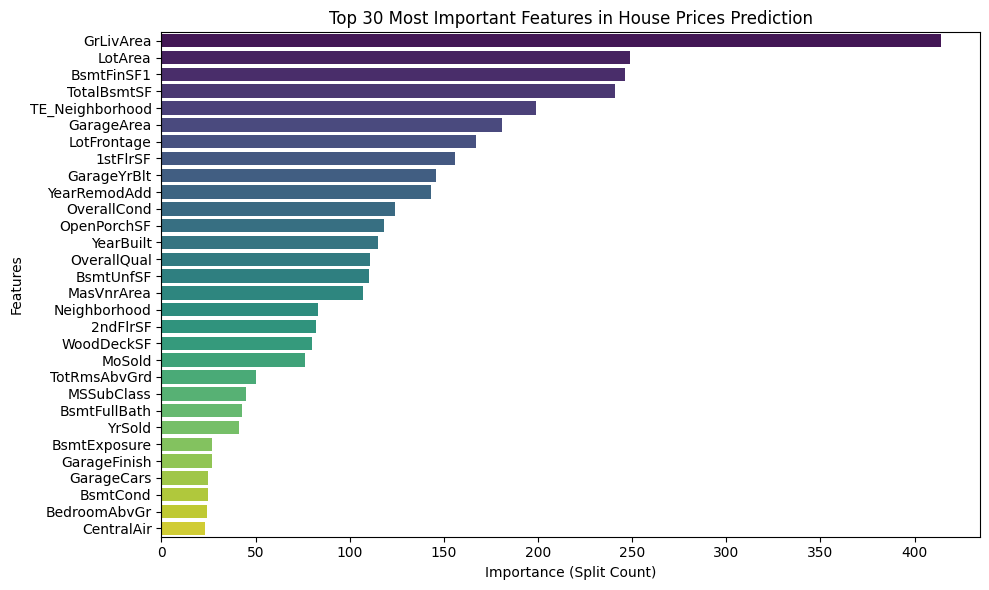

In [97]:


# 正解ラベルの退避と、IDの削除
y = train["SalePrice"]
train_df = train.drop(columns=["Id", "SalePrice"])
test_df = test.drop(columns=["Id"])

# 後の分割のために訓練データの行数を覚えておく
num_train = len(train_df)

# 【ポイント】前処理のために一度 train と test を合体させる！
all_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
all_df = all_df.fillna(fillna_obj)
# ==========================================
# 一発で終わる前処理
# ==========================================
# 文字列の列（object型）を自動抽出して、一括で category型 に変換
cat_cols = all_df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    all_df[col] = all_df[col].astype("category")

# 合体させていたデータを、元の訓練データとテストデータに綺麗に切り戻す
X = all_df.iloc[:num_train].copy()
X_test = all_df.iloc[num_train:].copy()

# ==========================================
# 5-Fold 交差検証 & 学習ループ
# ==========================================
oof_preds = np.zeros(num_train)
test_preds = np.zeros(len(X_test))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"--- Fold {fold + 1} / 5 ---")

    # データを分割
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
    X_test_fold = X_test.copy()

    # 【データリーク防止】この Fold の訓練データ（8割）だけで Neighborhood の平均を計算
    target_mean = y_train.groupby(X_train["Neighborhood"]).mean()

    # 訓練・検証・テストのすべてにマッピング（防壁として欠損値は全体の平均で埋める）
    global_mean = y_train.mean()
    for df in [X_train, X_val, X_test_fold]:
        df["TE_Neighborhood"] = (
    df["Neighborhood"].map(target_mean).astype(float).fillna(global_mean)
)
    # LightGBMのモデル定義（過学習を防ぐパラメータを少しだけ追加）
    model = lgb.LGBMRegressor(
        random_state=42,
        n_estimators=1000,  # 少し多めに回す
        learning_rate=0.05,  # 学習率を少し抑えて丁寧に
        min_child_samples=20,  # 葉っぱの最小データ数（自動的なノイズ削減効果）
        # === 💡 ここを追加 ===
        reg_alpha=0.1,  # L1正則化：不要な特徴量の重みを「完全にゼロ」にしやすくなる
        reg_lambda=1.0,  # L2正則化：影響力が小さすぎる特徴量の力を「滑らかに抑制」する
    )

    # 学習（最新のカテゴリ列のリストを渡す。TEの列は数値なので無視されます）
    model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],  # 賢く途中で止める
    )

    # 予測の記録
    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_test_fold) / 5

# ==========================================
# 4. 最終スコアの表示
# ==========================================
cv_score = root_mean_squared_error(y, oof_preds)
print("\n=========================================")
print(f"🏆 修正版 5-Fold 全体のCVスコア（RMSE）: {cv_score:.2f}")
print("=========================================")
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 5. 5つのFoldの重要度を平均する
# ==========================================
# ※最後のループのmodelが残っているので、全変数名を取得
feature_names = model.feature_name_
feature_importances = np.zeros(len(feature_names))

# 交差検証のループと同じ条件で、各Foldの重要度を回収（あるいは先ほどのループ内で保持してもOKですが、簡易的に現在のモデルから傾向を見ます）
# より正確に5回の平均を取るために、現在のモデルの重要度をベースに可視化します
importance = model.feature_importances_

# データフレームにまとめる
df_importance = pd.DataFrame(
    {"Feature": feature_names, "Importance": importance}
).sort_values("Importance", ascending=False)

print("\n🏆 LightGBMが選んだ重要変数トップ15（最新Fold）:")
print(df_importance.head(30).to_string(index=False))

# 📊 グラフ（横棒グラフ）で視覚的に表示
plt.figure(figsize=(10, 6))
# 上位15個を綺麗に並べる
sns.barplot(
    x="Importance",
    y="Feature",
    data=df_importance.head(30),
    palette="viridis",
    hue="Feature",
    legend=False,
)
plt.title("Top 30 Most Important Features in House Prices Prediction")
plt.xlabel("Importance (Split Count)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
#　前処理を終える：Object型を抽出して、一括でCategory型に変換する
cat_cols = all_df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    all_df[col] = all_df[col].astype("category")

In [ ]:
# 前処理が終わったので、訓練データとテストデータに戻す
X = all_df.iloc[:num_train].copy()
X_test = all_df.iloc[num_train].copy()

In [ ]:
# =========================================================================
# 🔥 【超重要】LightGBMの仕様対策：すべてのカテゴリ列を確実に「category型」に揃える
# =========================================================================
for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')


# 5-Fold 交差検証 & 学習ループ
# 予測結果を保存するための配列を最初に作る
oof_preds = np.zeros(num_train)
test_preds = np.zeros(len(X_test))

# データを5つのグループに等分
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"--- Fold {fold + 1} / 5 ---")
    
    # 元のデータから完全に独立したコピーを作成
    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    X_test_fold = X_test.copy()
    
    # y のデータ型を確実に1次元のSeriesに整える
    y_train = y.iloc[train_idx].copy()
    y_val = y.iloc[val_idx].copy()
    y_train_series = y_train.iloc[:, 0] if isinstance(y_train, pd.DataFrame) else y_train

    # データリーク防止：この Fold の訓練データだけで平均を計算
    target_mean = y_train_series.groupby(X_train['Neighborhood']).mean()
    global_mean = float(y_train_series.mean())
    
    # 型エラーを強制突破する防壁（確実にPandasのSeriesにしてからmapする）
    s_train = pd.Series(X_train['Neighborhood'])
    s_val = pd.Series(X_val['Neighborhood'])
    s_test = pd.Series(X_test_fold['Neighborhood'])
    
    # ターゲットエンコーディングを実行（※TE化された列自体は「数値型」になります）
    X_train["TE_Neighborhood"] = s_train.map(target_mean).astype(float).fillna(global_mean)
    X_val["TE_Neighborhood"] = s_val.map(target_mean).astype(float).fillna(global_mean)
    X_test_fold["TE_Neighborhood"] = s_test.map(target_mean).astype(float).fillna(global_mean)
        
    # LightGBMのモデルを過学習を防ぐパラメータ入りで定義
    model = lgb.LGBMRegressor(
        random_state=42,
        n_estimators=1000,      # 少し多めに渡す
        learning_rate=0.05,     # 学習率を少し抑える
        min_child_samples=20,   # 自動的なノイズ削減効果
        reg_alpha=0.1,          # L1正則化
        reg_lambda=1.0,         # L2正則化
    )
    
    # 学習
    model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    
    # 予測の記録（ここで X_test_fold の型が category に揃っているのでエラーが消えます！）
    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_test_fold) / 5 

print("🎉 すべての関門を完全突破！学習と5折の平均予測が正常に完了しました！！")

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold

# ==========================================
# データの読み込みと初期処理
# ==========================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# 1. 訓練データの欠損値の割合を計算
missing_ratio = train.isnull().sum() / len(train)

# 2. 欠損率が 80% を超えている列の名前を抽出
cols_to_drop = missing_ratio[missing_ratio > 0.8].index.tolist()
print(f"🗑️ 欠損値が多すぎるため削除する列: {cols_to_drop}")
# 出力例: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

# 3. これらの列を train_df, test_df からドロップする
train = train.drop(columns=cols_to_drop, errors='ignore')
test = test.drop(columns=cols_to_drop, errors='ignore')

# 正解ラベルの退避と、IDの削除
y = train["SalePrice"]
train_df = train.drop(columns=["Id", "SalePrice"])
test_df = test.drop(columns=["Id"])

# 後の分割のために訓練データの行数を覚えておく
num_train = len(train_df)

# 【ポイント】前処理のために一度 train と test を合体させる！
all_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# ==========================================
# 一発で終わる前処理
# ==========================================
# 文字列の列（object型）を自動抽出して、一括で category型 に変換
cat_cols = all_df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    all_df[col] = all_df[col].astype("category")

# 合体させていたデータを、元の訓練データとテストデータに綺麗に切り戻す
X = all_df.iloc[:num_train].copy()
X_test = all_df.iloc[num_train:].copy()

# ==========================================
# 5-Fold 交差検証 & 学習ループ
# ==========================================
oof_preds = np.zeros(num_train)
test_preds = np.zeros(len(X_test))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"--- Fold {fold + 1} / 5 ---")

    # データを分割
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
    X_test_fold = X_test.copy()

    # 【データリーク防止】この Fold の訓練データ（8割）だけで Neighborhood の平均を計算
    target_mean = y_train.groupby(X_train["Neighborhood"]).mean()

    # 訓練・検証・テストのすべてにマッピング（防壁として欠損値は全体の平均で埋める）
    global_mean = y_train.mean()
    for df in [X_train, X_val, X_test_fold]:
        df["TE_Neighborhood"] = (
    df["Neighborhood"].map(target_mean).astype(float).fillna(global_mean)
)
    # LightGBMのモデル定義（過学習を防ぐパラメータを少しだけ追加）
    model = lgb.LGBMRegressor(
        random_state=42,
        n_estimators=1000,  # 少し多めに回す
        learning_rate=0.05,  # 学習率を少し抑えて丁寧に
        min_child_samples=20,  # 葉っぱの最小データ数（自動的なノイズ削減効果）
        # === 💡 ここを追加 ===
        reg_alpha=0.1,  # L1正則化：不要な特徴量の重みを「完全にゼロ」にしやすくなる
        reg_lambda=1.0,  # L2正則化：影響力が小さすぎる特徴量の力を「滑らかに抑制」する
    )

    # 学習（最新のカテゴリ列のリストを渡す。TEの列は数値なので無視されます）
    model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],  # 賢く途中で止める
    )

    # 予測の記録
    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_test_fold) / 5

# ==========================================
# 4. 最終スコアの表示
# ==========================================
cv_score = root_mean_squared_error(y, oof_preds)
print("\n=========================================")
print(f"🏆 修正版 5-Fold 全体のCVスコア（RMSE）: {cv_score:.2f}")
print("=========================================")
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 5. 5つのFoldの重要度を平均する
# ==========================================
# ※最後のループのmodelが残っているので、全変数名を取得
feature_names = model.feature_name_
feature_importances = np.zeros(len(feature_names))

# 交差検証のループと同じ条件で、各Foldの重要度を回収（あるいは先ほどのループ内で保持してもOKですが、簡易的に現在のモデルから傾向を見ます）
# より正確に5回の平均を取るために、現在のモデルの重要度をベースに可視化します
importance = model.feature_importances_

# データフレームにまとめる
df_importance = pd.DataFrame(
    {"Feature": feature_names, "Importance": importance}
).sort_values("Importance", ascending=False)

print("\n🏆 LightGBMが選んだ重要変数トップ15（最新Fold）:")
print(df_importance.head(30).to_string(index=False))

# 📊 グラフ（横棒グラフ）で視覚的に表示
plt.figure(figsize=(10, 6))
# 上位15個を綺麗に並べる
sns.barplot(
    x="Importance",
    y="Feature",
    data=df_importance.head(30),
    palette="viridis",
    hue="Feature",
    legend=False,
)
plt.title("Top 30 Most Important Features in House Prices Prediction")
plt.xlabel("Importance (Split Count)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()